## CAM(Class Activation Map)

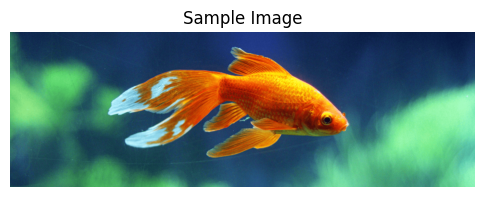

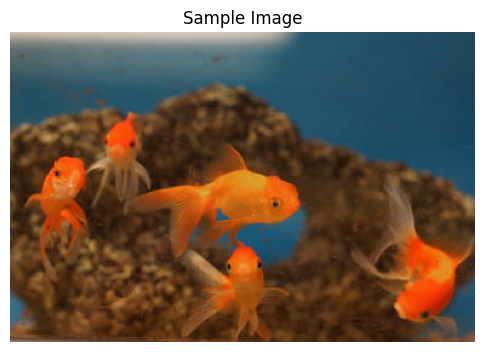

In [ ]:
# =========================================================================================
# 1. 라이브러리 임포트 (도구 상자 준비)
# =========================================================================================
# 이 스크립트에서 사용할 다양한 기능들을 담고 있는 '도구 상자'(라이브러리)들을 가져옵니다.

# 파이토치(PyTorch) 라이브러리입니다. 딥러닝 모델을 만들고 학습시키는 데 사용되는 핵심 프레임워크입니다.
# 이 코드에서는 직접 사용되지 않지만, torchvision이 의존하고 있으므로 보통 함께 임포트합니다.
import torch

# 파이토치의 컴퓨터 비전(computer vision)용 라이브러리입니다.
# models: ResNet, VGG 등 미리 학습된 유명한 딥러NING 모델들을 담고 있습니다.
# transforms: 이미지의 크기를 조절하거나, 잘라내거나, 텐서(tensor)로 변환하는 등 이미지 전처리에 필요한 기능들을 제공합니다.
from torchvision import models, transforms

# 'PIL' 또는 'Pillow'라고 불리는 라이브러리입니다. 파이썬에서 이미지를 열고, 수정하고, 저장하는 등
# 이미지 파일을 다루는 데 가장 기본적이고 널리 사용되는 도구입니다.
from PIL import Image

# 'requests'는 웹사이트에 접속하여 정보를 요청하고 받아오는 HTTP 통신을 쉽게 할 수 있도록 도와주는 라이브러리입니다.
# 웹에 있는 이미지를 다운로드하기 위해 사용합니다.
import requests

# 'io'는 입출력(Input/Output)을 다루는 라이브러리입니다.
# BytesIO는 일반적인 파일이 아닌, 메모리 상에 있는 바이너리(byte) 데이터를 파일처럼 다룰 수 있게 해주는 기능입니다.
# 다운로드한 이미지 데이터를 컴퓨터에 저장하지 않고 바로 사용하기 위해 필요합니다.
from io import BytesIO

# 'matplotlib'는 파이썬에서 가장 널리 사용되는 데이터 시각화 라이브러리입니다.
# pyplot은 그래프, 차트, 이미지 등을 화면에 표시하는 데 필요한 다양한 함수를 제공합니다.
# 'as plt'는 앞으로 matplotlib.pyplot을 'plt'라는 짧은 별명으로 부르겠다는 약속입니다.
import matplotlib.pyplot as plt


# =========================================================================================
# 2. 이미지 데이터 준비 (인터넷에서 이미지 다운로드 및 로드)
# =========================================================================================

# 첫 번째 이미지 파일이 있는 웹 주소(URL)를 문자열 변수 'url_1'에 저장합니다.
url_1 = 'https://petmedaily.com/wp-content/uploads/2022/12/Featured-Image-do-goldfish-get-lonely-1536x512.png'
# 두 번째 이미지 파일이 있는 웹 주소(URL)를 문자열 변수 'url_2'에 저장합니다.
url_2 = 'https://pethelpful.com/.image/w_384,q_auto:good,c_limit/MjEwNDM3MjkyNzE4ODI3MzQ1/easy-ways-to-keep-fish-alive-on-a-fish-bowl-without-air-pump.jpg'

# requests.get(url_1): url_1 주소로 HTTP GET 요청을 보내 웹 서버로부터 응답을 받아옵니다.
# response 변수에는 웹 서버의 응답(상태 코드, 헤더, 내용 등)이 담겨 있습니다.
response = requests.get(url_1)

# 받아온 응답(response)에서 순수한 이미지 데이터(바이너리) 부분만 .content를 통해 추출합니다.
# BytesIO(): 이 이미지 데이터를 '메모리 상의 가상 파일'로 만듭니다. (디스크에 저장하는 과정 생략)
# Image.open(): Pillow 라이브러리가 이 '가상 파일'을 열어서 이미지 객체로 만듭니다.
# .convert('RGB'): 이미지 포맷은 PNG(투명도 포함, RGBA)나 GIF 등 다양할 수 있습니다.
#                   딥러닝 모델은 보통 R, G, B 3개 채널만 사용하므로, 어떤 형식이든 확실하게 RGB로 변환하여 통일성을 확보합니다.
img1 = Image.open(BytesIO(response.content)).convert('RGB')

# 두 번째 이미지에 대해서도 위와 동일한 과정을 반복합니다.
response = requests.get(url_2)
img2 = Image.open(BytesIO(response.content)).convert('RGB')


# =========================================================================================
# 3. 원본 이미지 시각화 (화면에 표시)
# =========================================================================================

# plt.figure(): 이미지를 그릴 '도화지(figure)'를 하나 새로 준비합니다.
# figsize=(6,6): 이 도화지의 크기를 가로 6인치, 세로 6인치로 설정합니다.
plt.figure(figsize=(6,6))

# plt.imshow(img1): 준비된 도화지 위에 'img1' 이미지 객체를 그립니다.
plt.imshow(img1)

# plt.axis('off'): 이미지 주변에 기본으로 표시되는 x축, y축 눈금 및 선들을 모두 제거하여 깔끔하게 만듭니다.
plt.axis('off')

# plt.title("Sample Image"): 그려진 이미지의 상단에 "Sample Image"라는 제목을 추가합니다.
plt.title("Sample Image")

# plt.show(): 지금까지 메모리 상에서 준비된 모든 시각화 결과(도화지, 이미지, 제목 등)를
#             실제 화면에 창을 띄워 보여주는 최종 명령입니다. 이 명령이 없으면 그림이 보이지 않습니다.
plt.show()

# 두 번째 이미지(img2)에 대해서도 위와 동일한 시각화 과정을 반복합니다.
plt.figure(figsize=(6,6))
plt.imshow(img2)
plt.axis('off')
plt.title("Sample Image")
plt.show()

In [ ]:
# =========================================================================================
# (보충) 이미지 저장 예시
# =========================================================================================
# 이전에 메모리로 불러온 이미지 객체 'img1'을 실제 파일로 저장하는 명령입니다.
# ".save()"는 PIL 이미지 객체가 가진 기능(메서드)입니다.
# "img1.png"라는 이름으로, 이 파이썬 스크립트가 실행되는 폴더에 저장됩니다.
img1.save("img1.png")
img2.save("img2.png")

In [ ]:
# =========================================================================================
# 0. 라이브러리 다시 임포트
# =========================================================================================
# 스크립트의 각 부분을 독립적으로 실행할 수 있도록, 필요한 도구들을 다시 한번 명시적으로 가져옵니다.

import torch
# 파이토치의 신경망(Neural Network) 관련 기능들을 담고 있는 모듈입니다. nn.Sequential, nn.Module 등을 포함합니다.
from torch import nn
# 미리 학습된 모델, 이미지 변환(전처리) 기능 등을 제공하는 파이토치의 비전 라이브러리입니다.
from torchvision import models, transforms
# 파이토치의 함수형 API입니다. ReLU, Softmax 등 다양한 함수를 포함하고 있습니다.
from torch.nn import functional as F
from PIL import Image
import matplotlib.pyplot as plt

# =========================================================================================
# 1. 모델 준비: 사전학습된 ResNet-18 로드 및 평가 모드로 전환
# =========================================================================================

# models.resnet18(): torchvision의 models 모듈에서 ResNet-18 아키텍처를 생성하는 함수를 호출합니다.
# weights=... : 모델을 그냥 생성만 하는 것이 아니라, '사전 학습된 가중치(weights)'를 함께 불러오라는 명령어입니다.
#   "ResNet18_Weights.IMAGENET1K_V1"는 ImageNet이라는 1000개의 클래스를 가진 거대한 이미지 데이터셋으로
#   미리 훈련시켜 놓은, 검증된 가중치를 사용하겠다는 의미입니다.
#   이 덕분에 우리는 모델을 처음부터 학습시킬 필요 없이, 이미지를 잘 이해하는 '똑똑한' 모델을 바로 사용할 수 있습니다.
# .eval(): 모델을 '평가 모드(evaluation mode)'로 전환하는 매우 중요한 명령어입니다.
#   모델 내의 일부 레이어들(주로 BatchNorm, Dropout)은 훈련할 때와 예측할 때 다르게 동작합니다.
#   .eval()을 호출하면, 이 레이어들이 예측에 적합한 상태로 고정되어 일관성 있고 정확한 결과를 출력하게 됩니다.
#   (예: Dropout 비활성화, BatchNorm은 학습된 통계치 사용)
model = models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1").eval()


# =========================================================================================
# 2. 특징 추출기(Feature Extractor) 구성
# =========================================================================================
# ResNet-18 모델의 마지막 두 레이어(분류를 담당하는 부분)를 제거하여,
# 순수하게 이미지의 특징(feature)만 추출하는 새로운 모델을 만듭니다.

# 이 한 줄을 단계별로 분해해서 이해해 보겠습니다.
# 1. model.children():
#    - ResNet-18 모델 객체를 '해체'하여 그 구성 요소들(자식 모듈들)을 순서대로 꺼냅니다.
#    - 예: [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc]

# 2. list(...):
#    - 꺼내진 구성 요소들을 다루기 쉽도록 파이썬 '리스트(list)' 형태로 변환합니다.

# 3. [:-2]:
#    - 리스트 슬라이싱(slicing) 기능입니다. 리스트의 처음부터 끝에서 두 번째 앞까지의 요소만 선택하라는 의미입니다.
#    - 즉, 마지막 두 개의 요소인 'avgpool'과 'fc' (분류기)를 리스트에서 '제거'합니다.
#    - 이유: 'avgpool'과 'fc'는 추출된 특징을 요약하고 최종 클래스를 예측하는 역할입니다.
#            우리는 최종 예측이 아닌, 그 직전 단계의 풍부한 '특징 맵'을 원하기 때문에 이 부분은 잘라냅니다.

# 4. *...:
#    - '언패킹(Unpacking)' 연산자입니다.
#    - `[conv1, bn1, ..., layer4]` 와 같이 리스트에 담겨있던 요소들을
#    - `conv1, bn1, ..., layer4` 처럼 각각의 독립된 요소들로 풀어헤쳐 줍니다.

# 5. nn.Sequential(...):
#    - 풀어헤쳐진 각 레이어들을 다시 순서대로 차곡차곡 쌓아 하나의 새로운 신경망 모델로 '재조립'합니다.

# 최종 결과: features_extractor 라는 새로운 모델은 ResNet-18에서 분류기 부분만 떼어낸,
#            이미지의 특징을 추출하는 역할만 전문적으로 수행하는 '특징 추출기'가 됩니다.
#            이 모델에 이미지를 입력하면, 최종 분류 점수가 아닌 마지막 컨볼루션 레이어(layer4)를 통과한
#            '특징 맵(feature map)'이 출력됩니다.
features_extractor = nn.Sequential(*list(model.children())[:-2])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# =========================================================================================
# ResNet-18 모델 아키텍처 상세 해설
# =========================================================================================
# 아래 내용은 PyTorch로 ResNet-18 모델을 생성했을 때 출력되는 내부 구조입니다.
# 각 줄이 무엇을 의미하는지, 왜 그렇게 구성되었는지 상세히 설명합니다.
'''
ResNet(
'''
  # ---------------------------------------------------------------------------------------
  # [1단계] 입구 (Stem)
  # ---------------------------------------------------------------------------------------
  # 입력된 이미지를 본격적으로 분석하기 전에, 기본적인 특징을 추출하고 크기를 줄이는 사전 처리 단계입니다.

  # (conv1): 3채널(RGB) 이미지를 입력받아 64개의 특징 맵을 출력하는 첫 번째 컨볼루션 레이어입니다.
  #          kernel_size=(7, 7), stride=(2, 2): 큰 필터로 넓은 영역을 보며, 크기를 절반으로 줄입니다.
  '''
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  '''
  # (bn1): conv1을 통과한 64개 채널의 데이터 분포를 안정화시키는 배치 정규화(Batch Normalization)입니다.
  #        eps: 분모가 0이 되는 것을 방지하기 위한 작은 값입니다.
  #        affine=True: 스케일(gamma)과 쉬프트(beta) 파라미터를 학습한다는 의미입니다.
  '''
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  '''
  # (relu): 비선형성을 추가하는 ReLU 활성화 함수입니다.
  '''
  (relu): ReLU(inplace=True)
  '''
  # (maxpool): 특징 맵의 크기를 다시 절반으로 줄여 연산량을 줄이고 중요한 특징을 강조하는 최대 풀링입니다.
  '''
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  '''
  # ---------------------------------------------------------------------------------------
  # [2단계] 스테이지 1 (Layer1) - 2개 BasicBlock
  # ---------------------------------------------------------------------------------------
  # 목표: 크기는 유지하면서, 특징을 더 정교하게 다듬습니다. (채널: 64 -> 64)
  '''
  (layer1): Sequential(
  '''
    # (0): layer1의 첫 번째 BasicBlock입니다.
    '''
    (0): BasicBlock(
    '''
      # '국도(Main Path)'의 첫 번째 Conv입니다. 입력 64채널, 출력 64채널. stride=1이므로 크기는 변하지 않습니다.
      '''
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      '''
      # '국도'의 두 번째 Conv입니다.
      '''
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      '''
      # **주목**: 이 블록에는 'downsample'이 없습니다. 입력(64)과 출력(64)의 채널이 같고, 크기도 변하지 않기 때문입니다.
      #          따라서 '고속도로(Shortcut)'는 아무 공사 없이 '직진(Identity)'합니다.
    # (1): layer1의 두 번째 BasicBlock입니다. 위 첫 번째 블록과 구조가 완전히 동일합니다.
    '''
    (1): BasicBlock(...)
  )
  '''
  # ---------------------------------------------------------------------------------------
  # [3단계] 스테이지 2 (Layer2) - 2개 BasicBlock
  # ---------------------------------------------------------------------------------------
  # 목표: 크기를 절반으로 줄이고(다운샘플링), 채널을 두 배로 늘립니다. (채널: 64 -> 128)
  '''
  (layer2): Sequential(
  '''
    # (0): layer2의 첫 번째 BasicBlock입니다. 이 블록에서 '다운샘플링'이 일어납니다.
    '''
    (0): BasicBlock(
    '''
      # '국도'의 첫 Conv입니다. stride=(2, 2)를 통해 크기를 절반으로 줄이고, 채널을 64->128로 늘립니다.
      '''
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      '''
      # **주목**: 'downsample'이 존재합니다. '국도'의 크기와 채널이 모두 바뀌었기 때문입니다.
      #          이것이 바로 '고속도로 공사(Projection Shortcut)' 부분입니다.
      '''
      (downsample): Sequential(
        # (0): 1x1 Conv를 사용해 stride=2로 크기를 맞추고, 채널을 64->128로 효율적으로 변경합니다.
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    '''
    # (1): layer2의 두 번째 BasicBlock입니다.
    '''
    (1): BasicBlock(
    '''
      # 이제 입력 채널이 128이 되었습니다. 이 블록 내에서는 크기나 채널 변경이 없습니다.
      '''
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  )
      '''
      # ...
      # **주목**: 이 블록에는 'downsample'이 없습니다. 이제 이 스테이지 내에서는 차원이 안정화되었기 때문입니다.
      #          따라서 '고속도로'는 다시 '직진(Identity)'합니다.


  # ---------------------------------------------------------------------------------------
  # [4단계] 스테이지 3 (Layer3) - 2개 BasicBlock
  # ---------------------------------------------------------------------------------------
  # 목표: 크기를 다시 절반으로 줄이고, 채널을 두 배로 늘립니다. (채널: 128 -> 256)
  # 패턴: Layer2와 완벽히 동일합니다. 첫 번째 블록만 '고속도로 공사'를 하고, 두 번째는 '직진'합니다.
  '''
  (layer3): Sequential(
  '''
    # (0): layer3의 첫 번째 BasicBlock (다운샘플링 담당, 'downsample' 포함)
    '''
    (0): BasicBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      ...
      (downsample): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        ...
      )
    )
    '''
    # (1): layer3의 두 번째 BasicBlock (차원 유지, 'downsample' 없음)
    '''
    (1): BasicBlock(...)
  )
  '''
  # ---------------------------------------------------------------------------------------
  # [5단계] 스테이지 4 (Layer4) - 2개 BasicBlock
  # ---------------------------------------------------------------------------------------
  # 목표: 크기를 마지막으로 절반 줄이고, 채널을 두 배로 늘립니다. (채널: 256 -> 512)
  # 패턴: Layer2, 3과 완벽히 동일합니다.
  '''
  (layer4): Sequential(
  '''
    # (0): layer4의 첫 번째 BasicBlock (다운샘플링 담당, 'downsample' 포함)
    '''
    (0): BasicBlock(
      (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      ...
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
        ...
      )
    )
    '''
    # (1): layer4의 두 번째 BasicBlock (차원 유지, 'downsample' 없음)
    '''
    (1): BasicBlock(...)
  )
  '''
  # ---------------------------------------------------------------------------------------
  # [6단계] 출구 (Classifier)
  # ---------------------------------------------------------------------------------------
  # 최종적으로 추출된 특징을 보고 어떤 이미지인지 분류하는 단계입니다.

  # (avgpool): 최종 특징 맵(512채널, 7x7크기)의 공간 정보를 각 채널별 평균값 하나로 요약합니다.
  #            결과적으로 [B, 512, 1, 1] 형태의 텐서가 됩니다.
  '''
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  '''
  # (fc): 512개의 요약된 특징을 입력받아, 1000개의 클래스에 대한 최종 점수를 출력하는 완전 연결 계층입니다.
  '''
  (fc): Linear(in_features=512, out_features=1000, bias=True)
)
'''

In [ ]:
features_extractor

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

weights :  torch.Size([512, 1, 1])
feature map :  torch.Size([512, 7, 7])
cam :  (512, 1536)


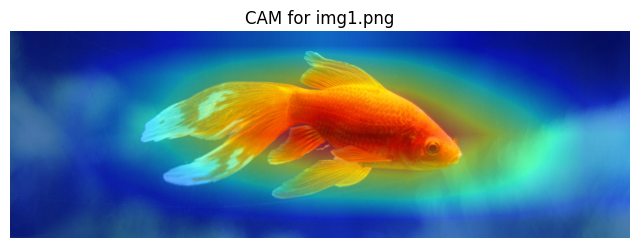

weights :  torch.Size([512, 1, 1])
feature map :  torch.Size([512, 7, 7])
cam :  (256, 384)


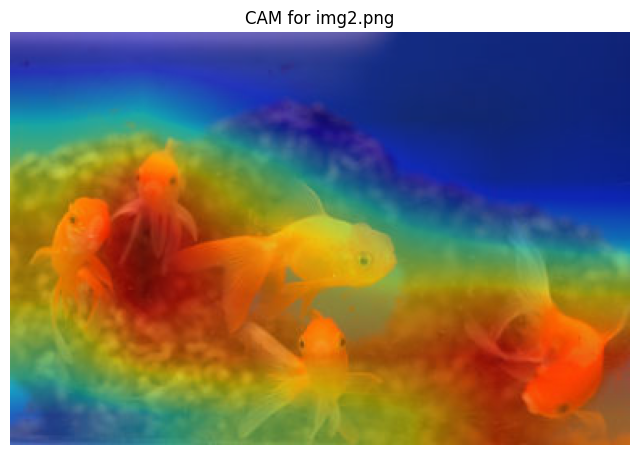

In [ ]:
import torch
from torch import nn
from torchvision import models, transforms
# torch.nn.functional은 가중치가 없는 연산들(활성화 함수, 풀링, 보간 등)을 함수 형태로 제공합니다.
from torch.nn import functional as F
from PIL import Image
import matplotlib.pyplot as plt

# =========================================================================================
# 1. 모델 준비: 사전학습된 ResNet-18 로드 및 특징 추출기 구성
# =========================================================================================
# 이전에 설명한 바와 같이, 사전 학습된 ResNet-18 모델을 불러와 '평가 모드'로 설정합니다.
model = models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1").eval()

# 모델의 마지막 분류 부분(avgpool, fc)을 제외하여,
# 마지막 컨볼루션 레이어의 출력, 즉 '특징 맵(feature map)'을 얻기 위한 모델을 별도로 구성합니다.
features_extractor = nn.Sequential(*list(model.children())[:-2])

# =========================================================================================
# 2. 이미지 전처리 정의: 이미지를 모델 입력에 적합한 형태로 변환하는 파이프라인
# =========================================================================================
# transforms.Compose는 여러 단계의 이미지 변환을 순서대로 실행하는 하나의 작업 흐름(파이프라인)으로 묶어줍니다.
transform = transforms.Compose([
    # transforms.Resize((224, 224)):
    #   - PIL 이미지의 크기를 (세로 224, 가로 224) 픽셀로 조절합니다.
    #   - ResNet과 같은 사전 학습된 모델들은 대부분 특정 크기의 이미지(예: 224x224)로 학습되었기 때문에,
    #     입력 이미지의 크기를 동일하게 맞춰주어야 합니다.
    transforms.Resize((224, 224)),

    # transforms.ToTensor():
    #   - 이 단계에서 두 가지 중요한 변환이 일어납니다.
    #   1. 데이터 형식 변환: 0~255 범위의 정수 값을 갖는 PIL 이미지를 0.0~1.0 범위의 소수 값을 갖는 파이토치 텐서(Tensor)로 변환합니다.
    #   2. 차원 순서 변경: (Height, Width, Channel) 순서의 이미지 데이터를 파이토치가 사용하는 (Channel, Height, Width) 순서로 재배열합니다.
    transforms.ToTensor(),

    # transforms.Normalize(...):
    #   - 텐서의 픽셀 값을 특정 평균(mean)과 표준편차(std)를 사용하여 정규화(normalize)합니다.
    #   - 여기에 사용된 평균/표준편차 값은 ResNet 모델이 학습되었던 ImageNet 데이터셋의 통계치입니다.
    #   - 우리가 입력하는 이미지의 데이터 분포를 모델이 학습했던 데이터의 분포와 유사하게 만들어주어, 모델의 성능을 최적화합니다.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# =========================================================================================
# 3. 처리할 이미지 파일 목록 준비
# =========================================================================================
# CAM을 계산하고 시각화할 이미지 파일들의 이름을 리스트에 저장합니다.
# 이전에 저장한 "img1.png", "img2.png" 파일을 사용합니다.
image_paths = ["img1.png", "img2.png"]

# =========================================================================================
# 4. 각 이미지에 대해 CAM 계산 및 시각화 (루프 실행)
# =========================================================================================
# for 루프를 사용하여 image_paths 리스트에 있는 각 이미지에 대해 아래의 과정을 반복합니다.
for image_path in image_paths:
    # 'image_path'에 해당하는 이미지 파일을 디스크에서 불러와 PIL 이미지 객체로 만듭니다.
    # .convert("RGB")를 통해 모든 이미지를 RGB 3채널 형식으로 통일합니다.
    image = Image.open(image_path).convert("RGB")

    # [전처리] 위에서 정의한 'transform' 파이프라인을 이미지에 적용합니다.
    #   - 결과: 이미지가 [3, 224, 224] 크기의 정규화된 텐서로 변환됩니다.
    # .unsqueeze(0): 파이토치 모델은 보통 여러 이미지를 한번에 처리하는 '배치(batch)' 단위로 입력을 받습니다.
    #                따라서 [3, 224, 224] 텐서에 맨 앞에 '배치' 차원을 하나 추가하여 [1, 3, 224, 224] 형태로 만들어줍니다.
    #                (1은 이미지 1장을 의미)
    target = transform(image).unsqueeze(0)

    # -----------------------------------------------------------------------------------
    # 4-1. 모델 순전파(Forward Pass)를 통해 예측 클래스 얻기
    # -----------------------------------------------------------------------------------
    # 전처리된 이미지 텐서('target')를 전체 모델('model')에 입력하여 최종 예측 결과를 얻습니다.
    # 'output'은 [1, 1000] 형태의 텐서로, 1000개 클래스에 대한 점수(logit)를 담고 있습니다.
    output = model(target)

    # output.argmax(): 1000개의 점수 중 가장 높은 값의 '인덱스(index)'를 찾습니다. 이 인덱스가 바로 모델이 예측한 클래스입니다.
    # int(...): 파이토치 텐서 형태의 인덱스를 일반 정수(integer)로 변환합니다.
    class_idx = int(output.argmax())

    # -----------------------------------------------------------------------------------
    # 4-2. 예측 클래스에 대한 가중치(Weight) 추출 (CAM의 핵심 1)
    # -----------------------------------------------------------------------------------
    # model.fc.weight: 모델의 마지막 완전 연결 계층(fc)의 전체 가중치 행렬([1000, 512])에 접근합니다.
    # [class_idx]: 이 행렬에서 모델이 예측한 클래스에 해당하는 '행(row)'만 추출합니다.
    #              이 행이 바로 해당 클래스를 결정하는 데 사용된 512개 특징 맵의 '중요도 가중치'입니다.
    # .reshape(-1, 1, 1): 추출된 가중치([512])를 특징 맵과 곱셈하기 위해 차원을 [512, 1, 1]로 변경합니다.
    weights = model.fc.weight[class_idx].reshape(-1, 1, 1)

    # -----------------------------------------------------------------------------------
    # 4-3. 마지막 컨볼루션 레이어의 특징 맵(Feature Map) 추출 (CAM의 핵심 2)
    # -----------------------------------------------------------------------------------
    # 이미지 텐서('target')를 분류기가 제거된 'features_extractor'에 통과시킵니다.
    #   - 결과: 마지막 컨볼루션 레이어(layer4)를 통과한 후의 최종 특징 맵이 출력됩니다. 형태는 [1, 512, 7, 7] 입니다.
    # .squeeze(): 불필요한 배치 차원(1)을 제거하여 [512, 7, 7] 형태로 만듭니다.
    features_output = features_extractor(target).squeeze()

    # -----------------------------------------------------------------------------------
    # 4-4. CAM 계산: 특징 맵과 가중치의 가중합(Weighted Sum)
    # -----------------------------------------------------------------------------------
    # features_output([512, 7, 7]) * weights([512, 1, 1]):
    #   - 512개의 각 특징 맵(7x7)에 해당하는 중요도 가중치를 곱해줍니다. (Broadcasting)
    # torch.sum(cam, dim=0):
    #   - 가중치가 곱해진 512개의 특징 맵들을 채널 방향(dim=0)으로 모두 더하여 하나의 맵으로 합칩니다.
    #   - 결과: [7, 7] 크기의 CAM(Class Activation Map)이 생성됩니다.
    #           이 맵의 밝은 부분은 모델이 예측을 내리는 데 중요하게 본 이미지 영역을 의미합니다.
    cam = features_output * weights
    cam = torch.sum(cam, dim=0)

    # -----------------------------------------------------------------------------------
    # 4-5. CAM 맵을 원본 이미지 크기로 확대
    # -----------------------------------------------------------------------------------
    # F.interpolate(): 텐서의 크기를 조절하는 함수입니다. (이미지 확대/축소와 유사)
    #   - input=...: [7, 7] 크기의 CAM에 다시 배치(0)와 채널(0) 차원을 추가하여 [1, 1, 7, 7] 형태로 만듭니다.
    #   - size=...: 목표 크기를 원본 이미지의 (높이, 너비)로 설정합니다.
    #   - mode="bilinear": 부드러운 시각적 결과를 위해 '쌍선형 보간법'을 사용합니다.
    # .squeeze().detach().numpy():
    #   - squeeze(): 추가했던 차원들을 다시 제거합니다.
    #   - detach(): 그래프 추적을 중단하여 NumPy 배열로 변환할 수 있도록 준비합니다.
    #   - numpy(): Matplotlib에서 사용하기 위해 파이토치 텐서를 NumPy 배열로 변환합니다.
    cam = F.interpolate(
        input=cam.unsqueeze(0).unsqueeze(0),
        size=(image.height, image.width),
        mode="bilinear"
    ).squeeze().detach().numpy()

    # -----------------------------------------------------------------------------------
    # 4-6. 원본 이미지와 CAM 맵을 겹쳐서 시각화
    # -----------------------------------------------------------------------------------
    # 이미지를 그릴 도화지를 준비합니다.
    plt.figure(figsize=(8, 8))
    # 1. 원본 이미지를 먼저 그립니다.
    plt.imshow(image)
    # 2. 그 위에 CAM 맵을 겹쳐서 그립니다.
    #    - cmap="jet": CAM의 값에 따라 색상을 입힙니다 (낮으면 파랑, 높으면 빨강).
    #    - alpha=0.5: CAM 맵을 50% 반투명하게 만들어 아래의 원본 이미지가 보이도록 합니다.
    plt.imshow(cam, cmap="jet", alpha=0.5)
    # 축 정보를 제거합니다.
    plt.axis("off")
    # 이미지 제목을 설정합니다.
    plt.title(f"CAM for {image_path}")
    # 최종 결과물을 화면에 보여줍니다.
    plt.show()

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [ ]:
# 'torchinfo' 라이브러리는 모델의 구조를 요약하여 보여주는 유용한 도구입니다.
# summary 함수는 모델과 입력 데이터의 크기를 인자로 받아,
# 각 계층(layer)을 통과할 때 데이터의 형태(Output Shape)가 어떻게 변하는지,
# 그리고 각 계층이 몇 개의 파라미터(Param #)를 가지고 있는지 한눈에 보여줍니다.
from torchinfo import summary

# 이전에 불러온 ResNet-18 모델('model')의 요약 정보를 출력합니다.
# input_size는 모델에 들어갈 가상의 입력 데이터 크기를 지정합니다.
# (배치크기=1, 채널=3, 높이=224, 너비=224)
summary(model, input_size=(1, 3, 224, 224))

# ==========================================================================================
# Layer (type:depth-idx)                   Output Shape              Param #
# ==========================================================================================
# Layer: 계층의 이름과 타입, 깊이(depth)와 순서(idx)를 나타냅니다.
# Output Shape: 해당 계층을 통과한 후 데이터의 형태 변화를 보여줍니다. [배치크기, 채널, 높이, 너비] 순서입니다.
# Param #: 해당 계층이 가지고 있는 학습 가능한 파라미터(가중치, 편향)의 총 개수입니다.

ResNet                                   [1, 1000]                 --
# ------------------------------------------------------------------------------------------
# [1단계] 입구 (Stem)
# ------------------------------------------------------------------------------------------
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
#▶ 7x7 Conv(S2). 입력 [1, 3, 224, 224] -> 출력 [1, 64, 112, 112]. 파라미터: (7*7*3)*64 = 9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
#▶ 64개 채널을 정규화. 파라미터: 64(gamma) + 64(beta) = 128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
#▶ 활성화 함수. 파라미터 없음.
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
#▶ 3x3 Pool(S2). 크기 절반 감소. 파라미터 없음.

# ------------------------------------------------------------------------------------------
# [2단계] 스테이지 1 (Layer1) - 2개 BasicBlock
# ------------------------------------------------------------------------------------------
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1 (Identity)        [1, 64, 56, 56]           --
#▶ 첫 번째 블록. 입력/출력 차원이 동일하므로 '고속도로'는 공사 없는 'Identity Shortcut'입니다.
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
#▶ '국도'의 첫 Conv. 파라미터: (3*3*64)*64 = 36,864
│    │    └─...
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
#▶ '국도'의 두 번째 Conv. 파라미터: (3*3*64)*64 = 36,864
│    │    └─...
│    └─BasicBlock: 2-2 (Identity)        [1, 64, 56, 56]           --
#▶ 두 번째 블록. 첫 번째 블록과 구조 및 파라미터가 완전히 동일합니다.
│    │    └─...

# ------------------------------------------------------------------------------------------
# [3단계] 스테이지 2 (Layer2) - 2개 BasicBlock
# ------------------------------------------------------------------------------------------
├─Sequential: 1-6                        [1, 128, 28, 28]          --
│    └─BasicBlock: 2-3 (Projection)      [1, 128, 28, 28]          --
#▶ 첫 번째 블록. 크기와 채널이 바뀌므로 '고속도로 공사(Projection Shortcut)'가 필요합니다.
│    │    └─Conv2d: 3-13                 [1, 128, 28, 28]          73,728
#▶ '국도'의 첫 Conv(S2). 입력 64채널->출력 128채널. 파라미터: (3*3*64)*128 = 73,728
│    │    └─...
│    │    └─Conv2d: 3-16                 [1, 128, 28, 28]          147,456
#▶ '국도'의 두 번째 Conv. 파라미터: (3*3*128)*128 = 147,456
│    │    └─Sequential: 3-18             [1, 128, 28, 28]          8,448
#▶ **이것이 바로 '고속도로 공사(downsample)' 부분입니다.** 1x1 Conv + BatchNorm으로 구성됩니다.
#▶ 파라미터: (1*1*64)*128(Conv) + 128*2(BN) = 8,192 + 256 = 8,448
│    │    └─...
│    └─BasicBlock: 2-4 (Identity)        [1, 128, 28, 28]          --
#▶ 두 번째 블록. 이제 차원이 안정화되었으므로 'Identity Shortcut'을 사용합니다.
│    │    └─Conv2d: 3-20                 [1, 128, 28, 28]          147,456
#▶ '국도'의 첫 Conv. 입력 128채널->출력 128채널. 파라미터: (3*3*128)*128 = 147,456
│    │    └─...

# ------------------------------------------------------------------------------------------
# [4단계] 스테이지 3 (Layer3) - 2개 BasicBlock
# ------------------------------------------------------------------------------------------
├─Sequential: 1-7                        [1, 256, 14, 14]          --
│    └─BasicBlock: 2-5 (Projection)      [1, 256, 14, 14]          --
#▶ 첫 번째 블록에서 다운샘플링 (128->256채널, 28x28->14x14). 'Projection Shortcut'이 필요합니다.
│    │    └─Conv2d: 3-26                 [1, 256, 14, 14]          294,912
#▶ '국도'의 첫 Conv(S2). 파라미터: (3*3*128)*256 = 294,912
│    │    └─Sequential: 3-31             [1, 256, 14, 14]          33,280
#▶ **'고속도로 공사(downsample)' 부분입니다.**
#▶ 파라미터: (1*1*128)*256(Conv) + 256*2(BN) = 32,768 + 512 = 33,280
│    │    └─...
│    └─BasicBlock: 2-6 (Identity)        [1, 256, 14, 14]          --
#▶ 두 번째 블록. 'Identity Shortcut'을 사용합니다.
│    │    └─...

# ------------------------------------------------------------------------------------------
# [5단계] 스테이지 4 (Layer4) - 2개 BasicBlock
# ------------------------------------------------------------------------------------------
├─Sequential: 1-8                        [1, 512, 7, 7]            --
│    └─BasicBlock: 2-7 (Projection)      [1, 512, 7, 7]            --
#▶ 첫 번째 블록에서 다운샘플링 (256->512채널, 14x14->7x7). 'Projection Shortcut'이 필요합니다.
│    │    └─Conv2d: 3-39                 [1, 512, 7, 7]            1,179,648
#▶ '국도'의 첫 Conv(S2). 파라미터: (3*3*256)*512 = 1,179,648
│    │    └─Sequential: 3-44             [1, 512, 7, 7]            132,096
#▶ **'고속도로 공사(downsample)' 부분입니다.**
#▶ 파라미터: (1*1*256)*512(Conv) + 512*2(BN) = 131,072 + 1024 = 132,096
│    │    └─...
│    └─BasicBlock: 2-8 (Identity)        [1, 512, 7, 7]            --
#▶ 두 번째 블록. 'Identity Shortcut'을 사용합니다.
│    │    └─...

# ------------------------------------------------------------------------------------------
# [6단계] 출구 (Classifier)
# ------------------------------------------------------------------------------------------
├─AdaptiveAvgPool2d: 1-9                 [1, 512, 1, 1]            --
#▶ 최종 특징 맵 [1, 512, 7, 7] -> [1, 512, 1, 1]로 공간 정보를 요약. 파라미터 없음.
├─Linear: 1-10                           [1, 1000]                 513,000
#▶ 512개 특징을 1000개 클래스로 분류. 파라미터: 512(입력) * 1000(출력) + 1000(편향) = 513,000

# ==========================================================================================
# [요약 정보]
# ==========================================================================================
Total params: 11,689,512
#▶ 모델에 포함된 모든 학습 가능한 파라미터(가중치, 편향)의 총 개수입니다.
Trainable params: 11,689,512
#▶ 이 중 실제로 학습(업데이트)되는 파라미터의 개수입니다. (모델을 동결하지 않았으므로 Total과 동일)
Non-trainable params: 0
#▶ 학습되지 않도록 동결(freeze)된 파라미터의 개수입니다.
Total mult-adds (Units.GIGABYTES): 1.81
#▶ 모델이 하나의 입력을 처리하는 데 필요한 곱셈-누산(Multiply-Adds) 연산의 총량입니다. 모델의 계산 복잡도를 나타내는 지표입니다. (1.81 Giga MACs)
# ==========================================================================================
# [메모리 사용량 예측]
# ==========================================================================================
Input size (MB): 0.60
#▶ 입력 텐서 [1, 3, 224, 224]가 차지하는 메모리 크기입니다.
Forward/backward pass size (MB): 39.75
#▶ 모델이 순전파/역전파를 수행할 때 중간 결과물(activation)들을 저장하는 데 필요한 메모리 크기입니다.
Params size (MB): 46.76
#▶ 모델의 파라미터 자체를 저장하는 데 필요한 메모리 크기입니다.
Estimated Total Size (MB): 87.11
#▶ 학습 시 GPU에 필요한 총 메모리의 예측치입니다. (위 세 항목의 합계와 유사)
# ==========================================================================================

## Grad-CAM

네, 제공해주신 Hook에 대한 설명은 매우 정확하고 핵심을 잘 담고 있습니다. 그 설명을 바탕으로, Grad-CAM의 맥락에서 Hook이 왜 필요하고 어떻게 작동하는지 비유를 통해 더 직관적으로 풀어드리겠습니다.

## Hook이란 무엇일까요? 🕵️
Hook은 한마디로 모델 내부에 설치하는 'CCTV' 또는 '도청 장치' 와 같습니다.

딥러닝 모델은 수많은 계층으로 이루어진 복잡한 '공장'과 같습니다. 데이터(원자재)가 들어가서 복잡한 공정(순전파)을 거쳐 최종 제품(예측 결과)이 나옵니다. 평소에는 이 공장이 어떻게 돌아가는지 내부를 들여다볼 수 없습니다. 중간 단계의 결과물들은 다음 단계로 넘어가면 바로 사라지기 때문입니다.

Hook은 이 공장의 특정 기계(레이어)에 CCTV를 설치해서, 그 기계에 '무엇이 들어오고(input), 무엇이 나가는지(output)' 를 실시간으로 엿볼 수 있게 해주는 장치입니다. 공장의 작동을 멈추거나 설계를 바꾸지 않고도 내부 정보를 빼낼 수 있는 것이 핵심입니다.

## Hook의 두 종류: 순방향 vs. 역방향
CCTV에도 종류가 있듯이, Hook에도 두 가지 종류가 있습니다.

1. 순전파 Hook (Forward Hook)
언제 작동하나요? 데이터가 입력단에서 출력단으로 순방향으로 흘러갈 때 작동합니다.

무엇을 볼 수 있나요? 특정 레이어의 **출력값(Feature Map)**을 볼 수 있습니다.

비유: 제품이 컨베이어 벨트를 따라 이동할 때, 특정 기계를 통과한 직후의 '반제품' 상태를 촬영하는 CCTV입니다. Grad-CAM에서는 마지막 컨볼루션 레이어가 만들어낸 최종 특징 맵을 얻기 위해 이 Forward Hook을 사용합니다.

2. 역전파 Hook (Backward Hook)
언제 작동하나요? 모델의 예측이 얼마나 틀렸는지 계산한 후, 그 오차 정보(Gradient)가 출력단에서 입력단으로 역방향으로 전파될 때 작동합니다.

무엇을 볼 수 있나요? 특정 레이어에 흐르는 **기울기(Gradient)**를 볼 수 있습니다.

비유: 최종 제품에 불량이 발견되어 "어느 공정에서 문제가 생겼나?"를 추적하는 신호(Gradient)를 역으로 보낼 때, 특정 기계에 이 신호가 얼마나 강하게 들어오는지 측정하는 '오류 감지 센서'입니다. 신호가 강할수록 그 기계가 최종 결과에 미친 영향이 크다는 뜻입니다.

## Grad-CAM에서 Hook을 사용하는 이유
Grad-CAM의 목표는 "모델이 특정 예측을 할 때, 이미지의 어느 영역을 중요하게 봤는지" 알아내는 것입니다. 이를 위해 두 가지 핵심 정보가 반드시 필요합니다.

"어떤 특징들을 감지했는가?" → 마지막 Conv 레이어의 특징 맵 (Feature Map)

"그 특징들 각각이 최종 예측에 얼마나 중요한 영향을 미쳤는가?" → 마지막 Conv 레이어의 기울기 (Gradient)

문제는 이 두 정보가 서로 다른 시점에 나타난다는 것입니다.

특징 맵: 순전파 시에 생성됩니다.

기울기: 역전파 시에 생성됩니다.

따라서, 우리는 이 두 가지 정보를 모두 '포획'하기 위해 목표 레이어(보통 마지막 Conv 레이어)에 두 종류의 Hook을 모두 설치해야 합니다.

register_forward_hook: 순전파가 일어날 때 특징 맵을 낚아챕니다.

register_backward_hook: 역전파가 일어날 때 기울기를 낚아챕니다.

이렇게 두 개의 Hook을 통해 얻어낸 '특징 맵' 과 '기울기' 를 조합하여 최종적인 Grad-CAM 히트맵을 만들게 됩니다. 결국 Hook은 Grad-CAM을 구현하기 위한 필수적인 '정보 수집 도구'인 셈입니다.

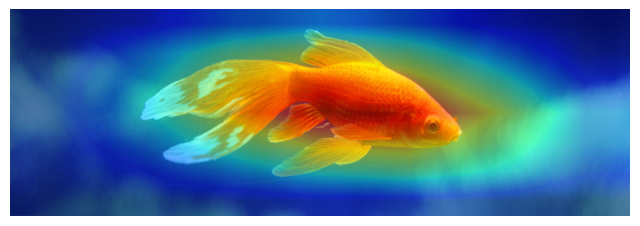

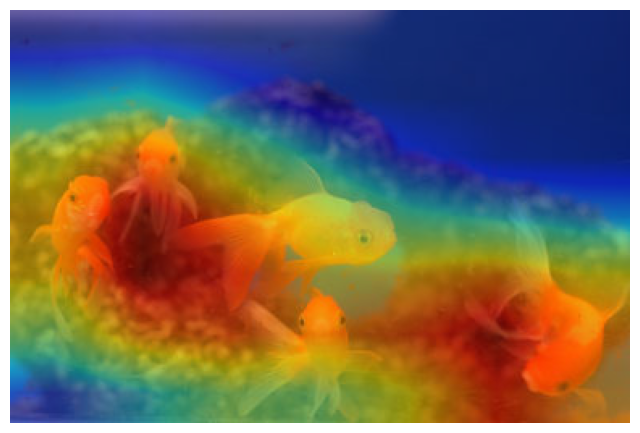

In [ ]:
import torch
from torch import nn
from torchvision import models, transforms
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt

# =========================================================================================
# Grad-CAM 알고리즘 구현 클래스
# =========================================================================================
# 이 클래스는 Grad-CAM을 생성하기 위한 하나의 '기계'라고 볼 수 있습니다.
# 모델과 관심 레이어를 지정하여 이 기계를 초기화하면,
# 이미지를 입력했을 때 해당 이미지가 특정 클래스로 예측되는 데 있어
# 모델이 어느 부분을 '주목'했는지를 보여주는 히트맵(heatmap)을 출력합니다.
class GradCAM:
    # -----------------------------------------------------------------------------------
    # 1. 생성자 함수 (__init__): Grad-CAM 기계 초기화
    # -----------------------------------------------------------------------------------
    # 이 클래스의 인스턴스(객체)를 처음 만들 때 실행되는 부분입니다.
    # 필요한 모델과 레이어 정보를 받아, Hook을 설치할 준비를 합니다.
    def __init__(self, model, target_layer):
        # self.model: 분석할 파이토치 모델을 저장합니다.
        self.model = model
        # self.target_layer: Hook을 설치할, 즉 우리가 관찰하고 싶은 특정 레이어를 저장합니다.
        self.target_layer = target_layer

        # self.feature_map: 순전파(forward) 시 target_layer의 출력(특징 맵)을 저장할 변수입니다.
        self.feature_map = None
        # self.gradient: 역전파(backward) 시 target_layer의 기울기(gradient)를 저장할 변수입니다.
        self.gradient = None

        # 모델을 평가 모드로 전환하고, 지정한 레이어에 Hook을 등록(설치)합니다.
        self.model.eval()
        self.register_hooks()

    # -----------------------------------------------------------------------------------
    # 2. Hook 등록 함수 (register_hooks): CCTV 및 센서 설치
    # -----------------------------------------------------------------------------------
    # 'CCTV'(순전파 Hook)와 '오류 감지 센서'(역전파 Hook)를 설치하는 함수입니다.
    def register_hooks(self):
        # self.forward_hook 함수를 self.target_layer에 '순전파 Hook'으로 등록합니다.
        # 이제부터 모델이 순전파를 수행할 때마다 self.target_layer를 통과한 직후,
        # self.forward_hook 함수가 자동으로 호출되어 그 출력(feature_map)을 낚아챕니다.
        self.target_layer.register_forward_hook(self.forward_hook)

        # self.backward_hook 함수를 self.target_layer에 '역전파 Hook'으로 등록합니다.
        # 이제부터 모델이 역전파를 수행할 때마다 self.target_layer에 도달하는 순간,
        # self.backward_hook 함수가 자동으로 호출되어 그 기울기(gradient)를 낚아챕니다.
        # register_full_backward_hook은 최신 파이토치 버전에서 권장되는 방식입니다.
        self.target_layer.register_full_backward_hook(self.backward_hook)

    # -----------------------------------------------------------------------------------
    # 3. Hook 콜백 함수들: 정보 수집 요원
    # -----------------------------------------------------------------------------------
    # register_hooks를 통해 설치된 Hook들이 실제로 실행하는 함수들입니다.

    # 순전파 시 자동으로 호출되는 'CCTV'입니다.
    # module: Hook이 등록된 레이어 자체 (self.target_layer)
    # input: 해당 레이어로 들어오는 입력
    # output: 해당 레이어에서 나가는 출력 (이것이 우리가 원하는 특징 맵입니다)
    def forward_hook(self, module, input, output):
        # 레이어의 출력(특징 맵)을 클래스 변수 self.feature_map에 저장합니다.
        self.feature_map = output

    # 역전파 시 자동으로 호출되는 '오류 감지 센서'입니다.
    # grad_input: 해당 레이어의 입력에 대한 기울기
    # grad_output: 해당 레이어의 출력에 대한 기울기 (이것이 우리가 원하는 기울기입니다)
    def backward_hook(self, module, grad_input, grad_output):
        # 레이어의 출력에 대한 기울기를 클래스 변수 self.gradient에 저장합니다.
        # PyTorch는 여러 출력을 가질 경우를 대비해 튜플(tuple) 형태로 전달하므로, 첫 번째 요소([0])를 선택합니다.
        self.gradient = grad_output[0]

    # -----------------------------------------------------------------------------------
    # 4. __call__: Grad-CAM 계산 실행 엔진
    # -----------------------------------------------------------------------------------
    # 이 클래스의 인스턴스를 함수처럼 호출할 수 있게 해줍니다. (예: grad_cam_machine(image_tensor))
    # Grad-CAM을 계산하는 전체 과정이 여기에 담겨 있습니다.
    def __call__(self, x, class_idx=None):
        # --- 4-1. 순전파 및 예측 클래스 결정 ---
        # 모델에 이미지를 통과시켜 최종 출력(1000개 클래스 점수)을 얻습니다.
        # 이 과정에서 self.target_layer를 지날 때 self.forward_hook이 자동으로 호출되어 self.feature_map이 저장됩니다.
        output = self.model(x)

        # 만약 특정 클래스를 지정하지 않았다면, 모델이 가장 높게 예측한 클래스를 사용합니다.
        if class_idx is None:
            class_idx = output.argmax(dim=1) # 가장 높은 점수의 인덱스를 찾습니다.

        # --- 4-2. 목표 클래스에 대한 역전파 준비 ---
        # one-hot 벡터를 만듭니다. 최종 출력과 똑같은 모양의 0으로 채워진 텐서를 만들고,
        # 우리가 관심 있는 (예측된) 클래스의 위치에만 1을 설정합니다.
        # 이유: 우리는 전체 오차(loss)가 아닌, '오직 특정 클래스의 점수'에 대한 기울기만 알고 싶기 때문입니다.
        one_hot = torch.zeros_like(output)
        one_hot[:, class_idx] = 1

        # --- 4-3. 역전파 실행 ---
        # 이전에 계산된 기울기가 남아있을 수 있으므로, 모델의 모든 기울기를 0으로 초기화합니다.
        self.model.zero_grad()
        # output.backward()를 통해 역전파를 시작합니다.
        # gradient=one_hot: 역전파를 시작할 초기 기울기로 one_hot 벡터를 사용합니다.
        #                   이렇게 하면, 최종 출력에서부터 거꾸로 '오직 class_idx에 해당하는 점수'의 영향력만 전파됩니다.
        # 이 과정에서 self.target_layer에 도달할 때 self.backward_hook이 자동으로 호출되어 self.gradient가 저장됩니다.
        output.backward(gradient=one_hot, retain_graph=True)

        # --- 4-4. Grad-CAM 계산 ---
        # a_k (가중치) 계산:
        #   - self.gradient: 역전파를 통해 얻은 기울기 [B, C, H, W]
        #   - torch.mean(...): 각 채널(C)별로 공간적(H, W) 평균을 구합니다. 이를 통해 각 특징 맵의 '중요도(a_k)'를 계산합니다.
        #                      결과 형태는 [B, C, 1, 1] 입니다.
        a_k = torch.mean(self.gradient, dim=(2, 3), keepdim=True)

        # grad_cam (가중합) 계산:
        #   - a_k * self.feature_map: 각 특징 맵([B, C, H, W])에 해당하는 중요도(a_k)를 곱해줍니다. (Broadcasting)
        #   - torch.sum(..., dim=1): 가중치가 적용된 모든 특징 맵들을 채널(C) 방향으로 모두 더하여 하나의 맵으로 합칩니다.
        grad_cam = torch.sum(a_k * self.feature_map, dim=1)

        # ReLU 적용:
        #   - 계산된 맵에서 0보다 작은 음수 값들은 제거합니다.
        #   - 최종 예측에 '긍정적인' 영향을 미친 영역에만 집중하기 위함입니다.
        grad_cam = torch.relu(grad_cam)

        # 계산된 Grad-CAM 맵을 반환합니다.
        return grad_cam

# =========================================================================================
# 이미지 전처리 및 Grad-CAM 적용 스크립트 상세 해설
# =========================================================================================

# -----------------------------------------------------------------------------------
# 1. 이미지 전처리 파이프라인 정의
# -----------------------------------------------------------------------------------
# 이전에 설명한 바와 같이, ResNet 모델에 이미지를 입력하기 전에
# 크기, 데이터 형식, 데이터 분포를 모델 학습 당시와 동일한 조건으로 맞춰주는
# '전처리 작업 흐름(transform)'을 정의합니다.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# -----------------------------------------------------------------------------------
# 2. 이미지 로드 및 배치(Batch) 생성
# -----------------------------------------------------------------------------------
# 분석할 이미지 파일들의 경로를 문자열 리스트로 관리합니다.
files = ["img1.png", "img2.png"]

# 원본 PIL 이미지(시각화용)와 전처리된 텐서(모델 입력용)를 저장할 빈 리스트를 생성합니다.
images = []
tensors = []

# files 리스트에 있는 각 파일 경로에 대해 반복 작업을 수행합니다.
for file in files:
    # PIL 라이브러리를 사용해 디스크에서 이미지 파일을 불러옵니다.
    image = Image.open(file)
    # 불러온 원본 이미지를 시각화를 위해 'images' 리스트에 추가합니다.
    images.append(image)
    # 이미지를 위에서 정의한 'transform' 파이프라인에 통과시켜 전처리한 후,
    # 그 결과(텐서)를 'tensors' 리스트에 추가합니다.
    tensors.append(transform(image))

# torch.stack(tensors):
#   - 'tensors' 리스트에는 현재 여러 개의 [3, 224, 224] 모양 텐서들이 들어있습니다.
#   - stack 함수는 이 텐서들을 쌓아서 하나의 '배치(batch)' 텐서로 만들어줍니다.
#   - 결과적으로 'tensors'는 [2, 3, 224, 224] 모양의 단일 텐서가 됩니다.
#     (2는 이미지의 개수, 즉 배치 크기)
tensors = torch.stack(tensors)

# -----------------------------------------------------------------------------------
# 3. Grad-CAM 생성기 객체 초기화
# -----------------------------------------------------------------------------------
# 이전에 우리가 상세히 분석했던 GradCAM 클래스의 인스턴스(객체)를 생성합니다.
# 이 객체는 지정된 모델과 레이어에 대한 Grad-CAM을 계산하는 '기계' 역할을 합니다.
grad_cam_generator = GradCAM(
    # model: Grad-CAM을 계산할 기반 모델을 지정합니다. (사전 학습된 ResNet-18)
    model=models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1"),
    # main_layer_name: Hook을 설치할 상위 모듈의 이름입니다. ResNet-18의 마지막 스테이지인 'layer4'를 지정합니다.
    main_layer_name="layer4",
    # sub_layer_name: 'layer4' 내부에서도, 그 마지막 블록의 'conv2' 레이어에 Hook을 설치하도록 지정합니다.
    #                 이곳이 바로 특징 맵과 기울기를 추출할 '관찰 지점'이 됩니다.
    sub_layer_name="conv2"
)

# -----------------------------------------------------------------------------------
# 4. Grad-CAM 계산 실행
# -----------------------------------------------------------------------------------
# grad_cam_generator 객체를 함수처럼 호출하여(__call__ 메서드 실행),
# 준비된 배치 텐서('tensors')에 대한 Grad-CAM을 계산합니다.
# 이 한 줄의 코드가 내부적으로 순전파, 역전파, 가중치 계산, 가중합 등 모든 복잡한 과정을 수행합니다.
# 'grad_cams'는 [2, 7, 7] 모양의 텐서로, 두 이미지 각각에 대한 7x7 크기의 히트맵을 담고 있습니다.
grad_cams = grad_cam_generator(tensors)

# -----------------------------------------------------------------------------------
# 5. 결과 시각화
# -----------------------------------------------------------------------------------
# enumerate(images)를 통해 각 이미지와 그 순서(idx)를 함께 가져와 반복합니다.
for idx, image in enumerate(images):
    # F.interpolate 함수를 사용하여 작은 크기의 Grad-CAM 맵을 원본 이미지와 동일한 크기로 확대(보간)합니다.
    #   - input=grad_cams[idx]...: 현재 순서(idx)에 맞는 CAM 결과([7, 7])를 선택하고,
    #                              interpolate 함수가 요구하는 4D 텐서 형태([1, 1, 7, 7])로 만들어줍니다.
    #   - size=(...): 목표 크기를 원본 이미지의 (높이, 너비)로 설정합니다.
    #                 (참고: PIL의 image.size는 (너비, 높이) 순서이므로, 인덱스를 [1], [0] 순으로 사용합니다.)
    #   - mode="bilinear": 부드러운 확대 결과를 위한 쌍선형 보간법을 사용합니다.
    # .squeeze().detach().numpy(): 최종 시각화를 위해 텐서를 NumPy 배열로 변환합니다.
    cam_resized = F.interpolate(
        input=grad_cams[idx].unsqueeze(0).unsqueeze(0),
        size=(image.size[1], image.size[0]),
        mode="bilinear",
    ).squeeze().detach().numpy()

    # Matplotlib을 사용하여 시각화를 준비합니다.
    plt.figure(figsize=(8, 8))
    # 1. 배경으로 원본 이미지를 먼저 그립니다.
    plt.imshow(image)
    # 2. 그 위에 확대된 CAM 맵을 겹쳐서 그립니다.
    #    - cmap="jet": 값의 크기에 따라 파랑(낮음) ~ 빨강(높음) 스펙트럼으로 색을 입힙니다.
    #    - alpha=0.5: 50% 반투명하게 만들어 아래의 원본 이미지가 비쳐 보이도록 합니다.
    plt.imshow(cam_resized, cmap="jet", alpha=0.5)
    # 불필요한 축 정보를 숨깁니다.
    plt.axis("off")
    # 화면에 최종 이미지를 표시합니다.
    plt.show()